# Smartphone data exploration

This study rebuilds a public Kaggle notebook on the UCI HAR smartphone data. People wore a phone on the waist and did simple activities such as walking, sitting and lying down. You will look at the features, draw a map of all windows, train a classifier, tell people apart by their movement and estimate how fast they walk.

Run the cells from top to bottom. Every step saves its tables and figures in the results folder and shows the main ones here.

In [1]:
dataRoot = "/app/data"
resultsRoot = "/app/results"
randomSeed = 42
nJobs = 4

In [2]:
from dataFetch.fetchData import dataFetcher

dataFetcher(dataRoot, nJobs=nJobs).fetchAll(["uciHar"])

[ DATA FETCH : ALREADY PRESENT ] : uciHar


## Set up the study

This step creates the study object from the settings above. It also fixes the random seeds, the thread limits and the plot style. This is done once, so that every run gives the same files.

In [3]:
from IPython.display import Image, display

from common.csvWriters import readCsv
from smartphoneExploration.smartphoneExplorer import smartphoneExplorer

explorer = smartphoneExplorer(dataRoot, resultsRoot, randomSeed=randomSeed, nJobs=nJobs)
explorer.prepareRun()
resultsDirectory = explorer.resultsDirectory
figuresDirectory = explorer.figuresDirectory

## Load the data

This step reads the UCI HAR files into one table. Each row is one window of sensor data with its summary features, the person and the activity. It also reads the raw signals and finds which windows follow each other in the same recording. The table below links each feature name to a unique name, because some names appear more than once in the dataset.

In [4]:
featureFrame = explorer.loadData()
display(readCsv(resultsDirectory / "featureNameMapping.csv").head(10))

[ SMARTPHONE : WINDOWS AND FEATURES ] : 10299 x 561


,featureIndex,originalName,uniqueName,occurrence,nameCount,renamed
0,1,tBodyAcc-mean()-X,tBodyAcc-mean()-X,1,1,False
1,2,tBodyAcc-mean()-Y,tBodyAcc-mean()-Y,1,1,False
2,3,tBodyAcc-mean()-Z,tBodyAcc-mean()-Z,1,1,False
3,4,tBodyAcc-std()-X,tBodyAcc-std()-X,1,1,False
4,5,tBodyAcc-std()-Y,tBodyAcc-std()-Y,1,1,False
5,6,tBodyAcc-std()-Z,tBodyAcc-std()-Z,1,1,False
6,7,tBodyAcc-mad()-X,tBodyAcc-mad()-X,1,1,False
7,8,tBodyAcc-mad()-Y,tBodyAcc-mad()-Y,1,1,False
8,9,tBodyAcc-mad()-Z,tBodyAcc-mad()-Z,1,1,False
9,10,tBodyAcc-max()-X,tBodyAcc-max()-X,1,1,False


## Feature groups

The features have names such as tBodyAcc-mean()-X. This step counts how many features belong to each group, using the part of the name before the first dash. The figure shows which signals have the most features.

,featureGroup,featureCount
0,tBodyAcc,40
1,tGravityAcc,40
2,tBodyAccJerk,40
3,tBodyGyro,40
4,tBodyGyroJerk,40
5,tBodyAccMag,13
6,tGravityAccMag,13
7,tBodyAccJerkMag,13
8,tBodyGyroMag,13
9,tBodyGyroJerkMag,13


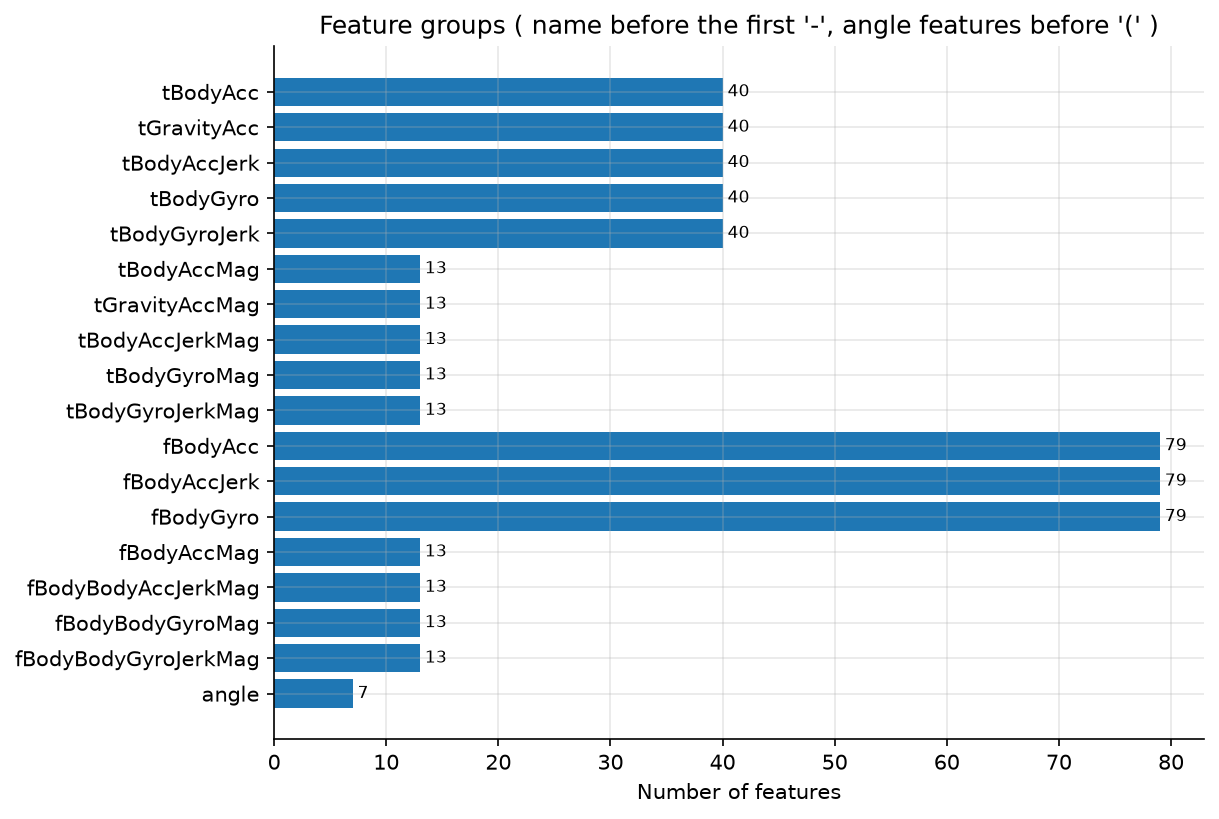

In [5]:
groupTable = explorer.exploreFeatureGroups()
display(readCsv(resultsDirectory / "featureGroups.csv").head(10))
display(Image(filename=figuresDirectory / "featureGroups.png"))

## Activity distribution

This step counts the windows of each activity in the train part and in the test part. It shows whether the activities are balanced. The seconds column turns the window counts into recording time.

,Activity,Train,Test,Total,share,seconds
0,WALKING,1226,496,1722,0.167201,2204.16
1,WALKING_UPSTAIRS,1073,471,1544,0.149917,1976.32
2,WALKING_DOWNSTAIRS,986,420,1406,0.136518,1799.68
3,SITTING,1286,491,1777,0.172541,2274.56
4,STANDING,1374,532,1906,0.185067,2439.68
5,LAYING,1407,537,1944,0.188756,2488.32


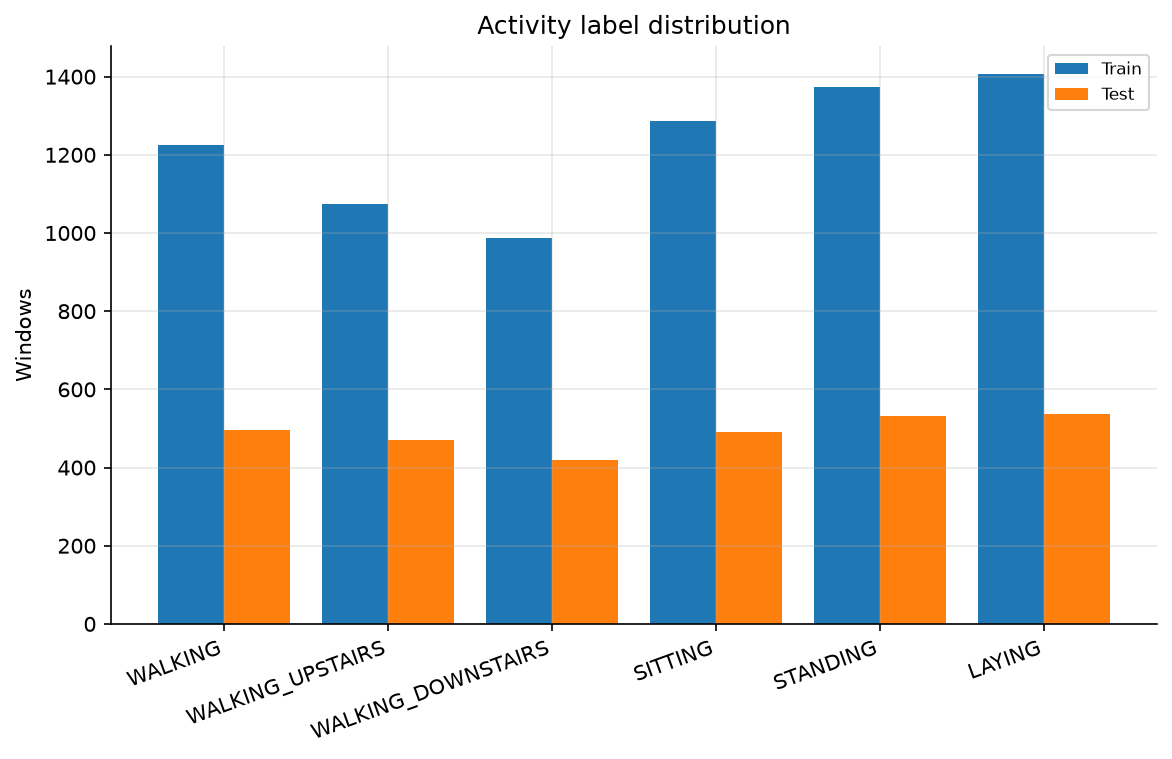

In [6]:
countTable = explorer.exploreActivityDistribution()
display(readCsv(resultsDirectory / "activityDistribution.csv").head(10))
display(Image(filename=figuresDirectory / "activityDistribution.png"))

## t-SNE map

This step squeezes all features into two dimensions so that we can look at them. It first standardises the features and keeps the main directions with PCA, then it runs t-SNE. Windows of the same activity should sit close together on the map. The second figure colours the same map by person. This step is slower than the others.

[ SMARTPHONE : TSNE KL DIVERGENCE ] : 1.7755


,component,explainedVarianceRatio,cumulativeExplainedVarianceRatio
0,1,0.507382,0.507382
1,2,0.062392,0.569774
2,3,0.026926,0.596700
3,4,0.024529,0.621228
4,5,0.018889,0.640118
5,6,0.016314,0.656432
6,7,0.014145,0.670577
7,8,0.012162,0.682739
8,9,0.009852,0.692592
9,10,0.009492,0.702084


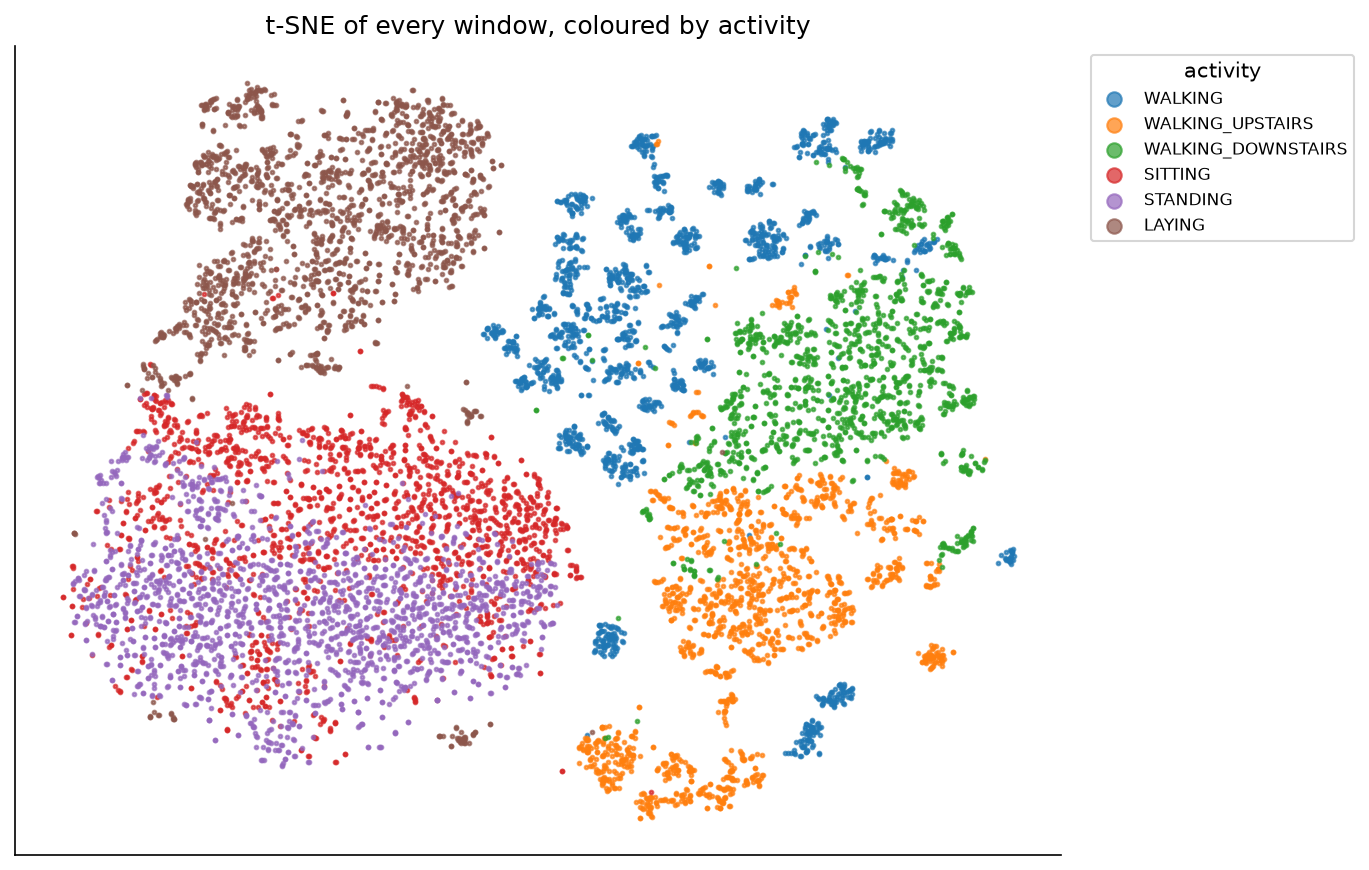

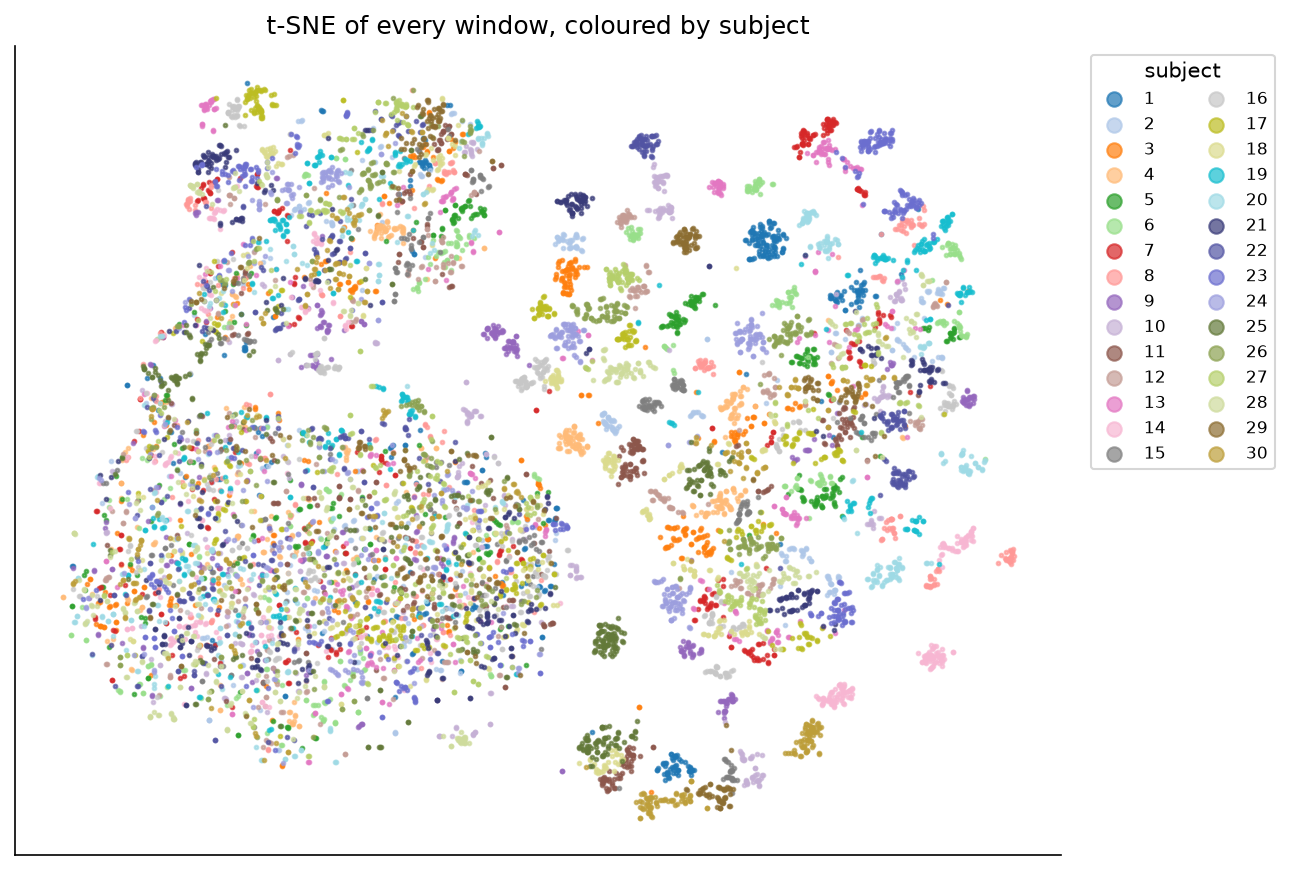

In [7]:
tsneCoordinates = explorer.embedWindows()
display(readCsv(resultsDirectory / "pcaExplainedVariance.csv").head(10))
display(Image(filename=figuresDirectory / "tsneByActivity.png"))
display(Image(filename=figuresDirectory / "tsneBySubject.png"))

## Activity classifier

This step trains a LightGBM classifier on the train part of the dataset and tests it on the test part. The people in the two parts are different, so the test shows how well the model works for new people. The confusion matrix shows which activities get mixed up.

[ SMARTPHONE : ACTIVITY ACCURACY ] : 0.9318


,accuracy,macroF1,trainWindows,testWindows,trainSubjects,testSubjects,sharedSubjects
0,0.931795,0.931281,7352,2947,21,9,0


,Activity,precision,recall,f1,testWindows
0,WALKING,0.927342,0.977823,0.951914,496
1,WALKING_UPSTAIRS,0.937365,0.921444,0.929336,471
2,WALKING_DOWNSTAIRS,0.967581,0.923810,0.945189,420
3,SITTING,0.926267,0.818737,0.869189,491
4,STANDING,0.848896,0.939850,0.892061,532
5,LAYING,1.000000,1.000000,1.000000,537


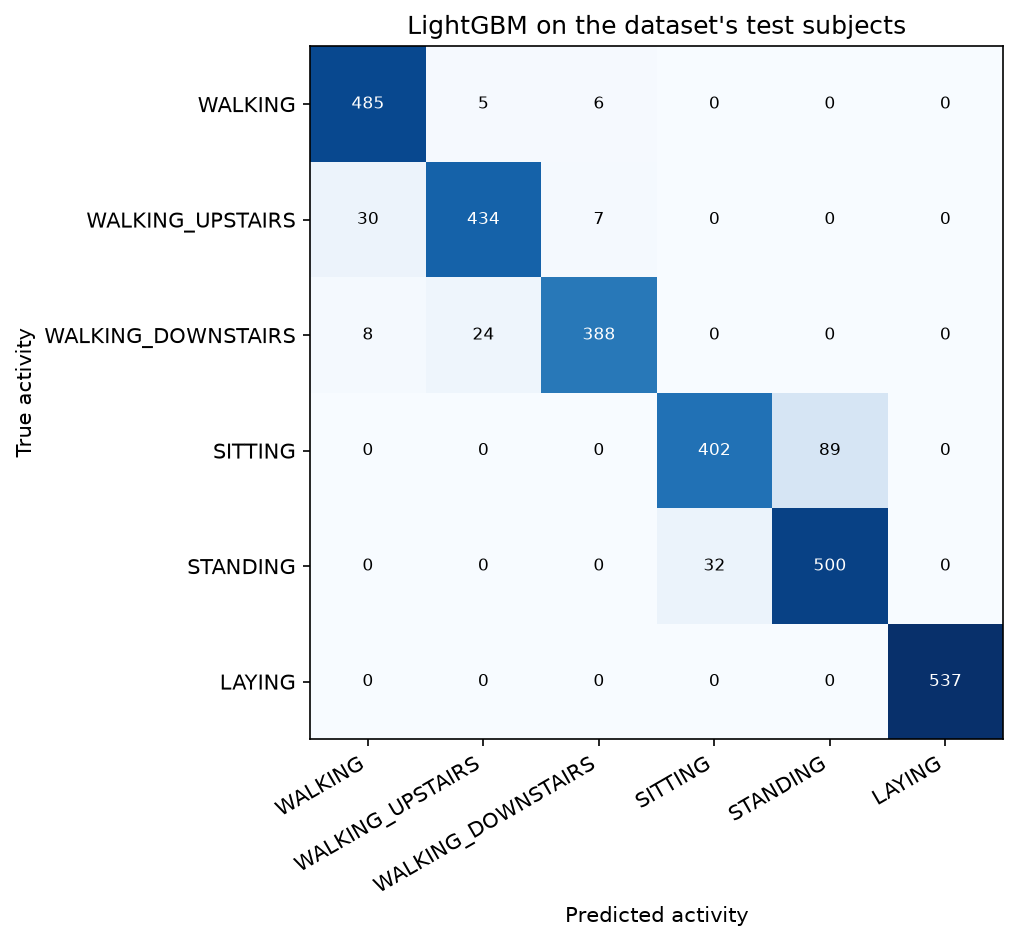

In [8]:
metricTable = explorer.classifyActivities()
display(readCsv(resultsDirectory / "activityClassification.csv"))
display(readCsv(resultsDirectory / "activityClassReport.csv"))
display(Image(filename=figuresDirectory / "activityConfusionMatrix.png"))

## Participant identification

This step asks a different question: which person made this window? It trains one classifier for each activity. Two ways of testing are compared. A random split of the windows is easy, because neighbouring windows share half of their raw samples. Holding out whole recordings is harder and tells you more. The last figure shows how many seconds of data each person has.

[ SMARTPHONE : PARTICIPANT ACCURACY WALKING ] : 0.9977


[ SMARTPHONE : PARTICIPANT ACCURACY WALKING_UPSTAIRS ] : 0.9793


[ SMARTPHONE : PARTICIPANT ACCURACY WALKING_DOWNSTAIRS ] : 0.9886


[ SMARTPHONE : PARTICIPANT ACCURACY SITTING ] : 0.8135


[ SMARTPHONE : PARTICIPANT ACCURACY STANDING ] : 0.8553


[ SMARTPHONE : PARTICIPANT ACCURACY LAYING ] : 0.9259


,Activity,windows,trainWindows,testWindows,participants,accuracy,macroF1,testWindowsWithTrainNeighbour,boutHeldOutFolds,boutHeldOutAccuracyMean,boutHeldOutAccuracyStd,boutHeldOutMacroF1Mean,boutHeldOutMacroF1Std,testSubjectsWithoutTrainingBouts,meanSecondsPerParticipant,medianSecondsPerParticipant,minSecondsPerParticipant,maxSecondsPerParticipant
0,WALKING,1722,1291,431,30,0.997680,0.997531,395,4,0.959961,0.005507,0.958084,0.005397,0,73.472000,72.96,58.88,121.60
1,WALKING_UPSTAIRS,1544,1158,386,30,0.979275,0.979352,341,4,0.939815,0.009963,0.937271,0.007891,0,65.877333,65.28,51.20,83.20
2,WALKING_DOWNSTAIRS,1406,1054,352,30,0.988636,0.988064,318,4,0.896125,0.006100,0.885920,0.007299,0,59.989333,59.52,46.08,79.36
3,SITTING,1777,1332,445,30,0.813483,0.803402,406,4,0.155391,0.067527,0.140849,0.058679,0,75.818667,74.24,56.32,108.80
4,STANDING,1906,1429,477,30,0.855346,0.851080,436,4,0.347373,0.059501,0.295562,0.041368,0,81.322667,78.08,56.32,113.92
5,LAYING,1944,1458,486,30,0.925926,0.921175,459,4,0.487762,0.106403,0.445828,0.102855,0,82.944000,85.12,61.44,115.20


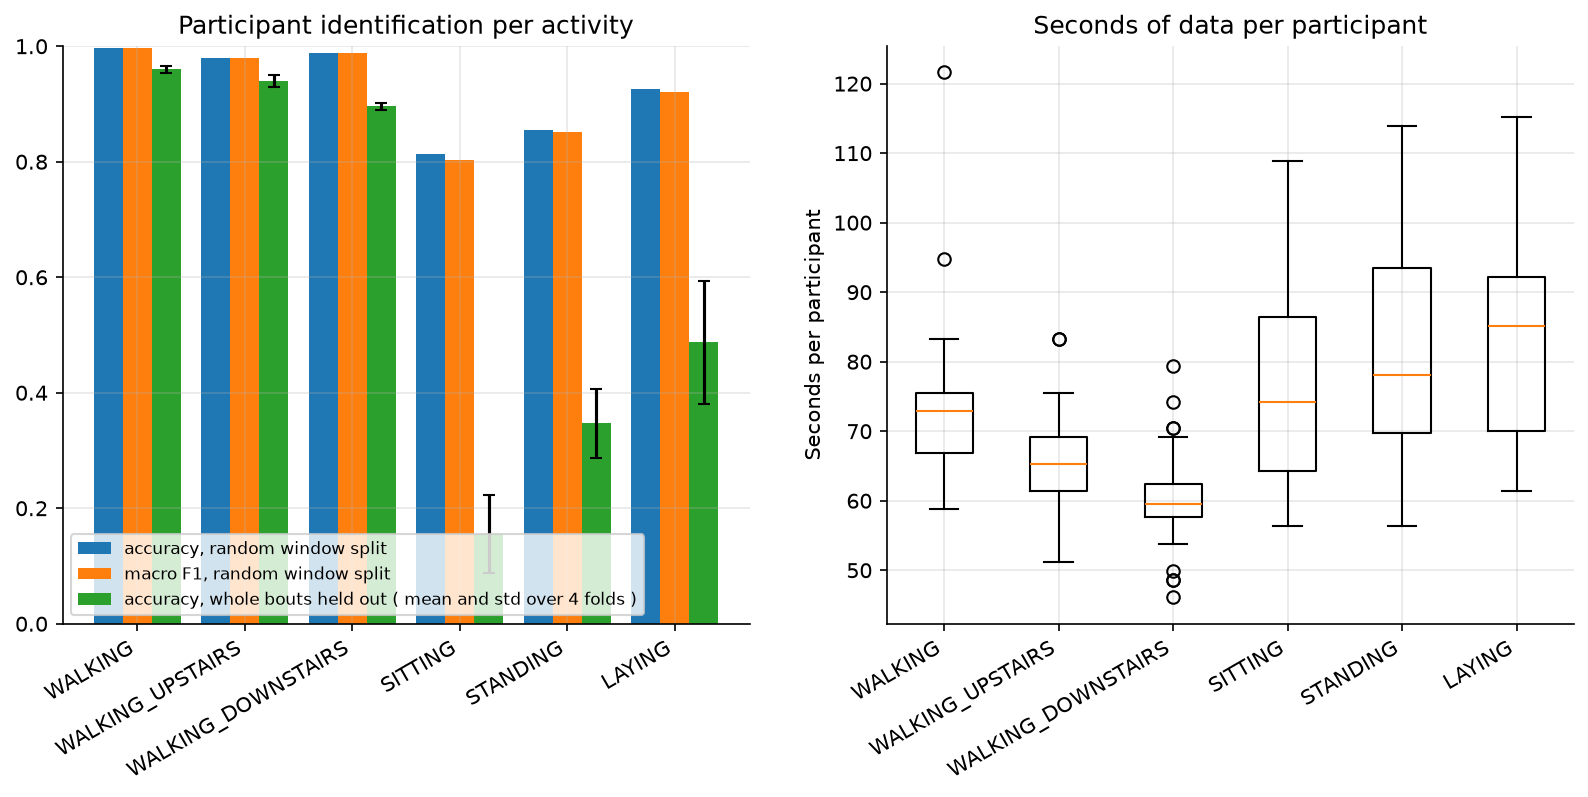

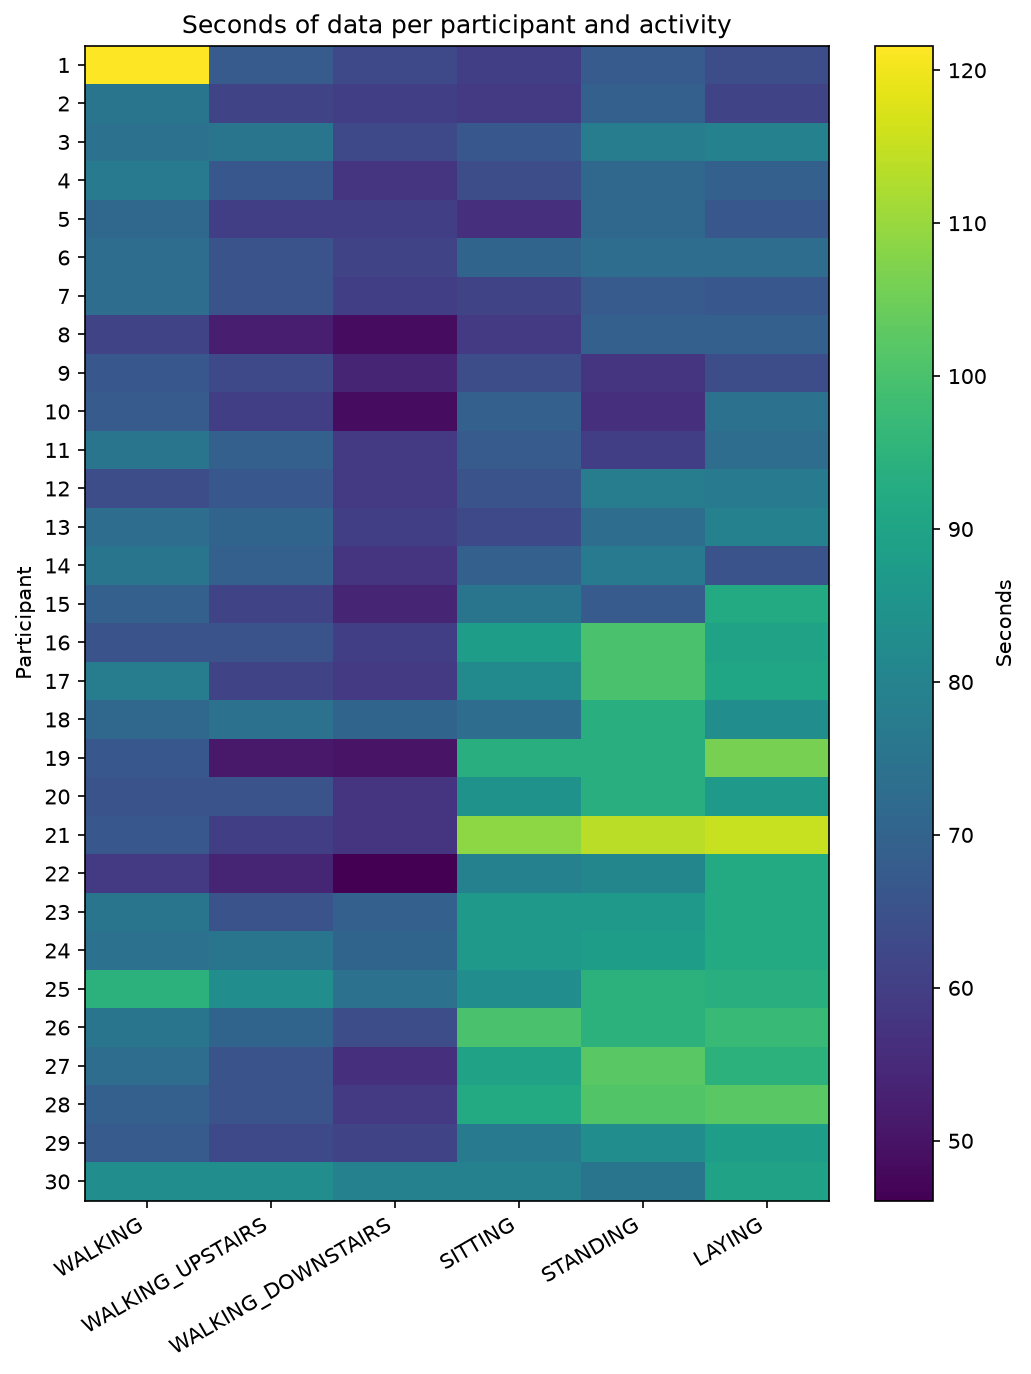

In [9]:
identificationTable = explorer.identifyParticipants()
display(readCsv(resultsDirectory / "participantIdentification.csv").head(10))
display(Image(filename=figuresDirectory / "participantIdentification.png"))
display(Image(filename=figuresDirectory / "participantDurations.png"))

## Accelerometer or gyroscope

This step looks inside the walking classifier from the last step. It adds up how much the model relies on accelerometer features and on gyroscope features. A sensor with many features is not always the one the model uses most. The table compares the share of features with the share of importance.

,sensor,features,splitImportance,gainImportance,featureShare,splitShare,gainShare
0,Acc,345,21937,25382.673969,0.614973,0.539019,0.522735
1,Gyro,213,18369,20857.114273,0.379679,0.451349,0.429535
2,Other,3,392,2317.647673,0.005348,0.009632,0.047730


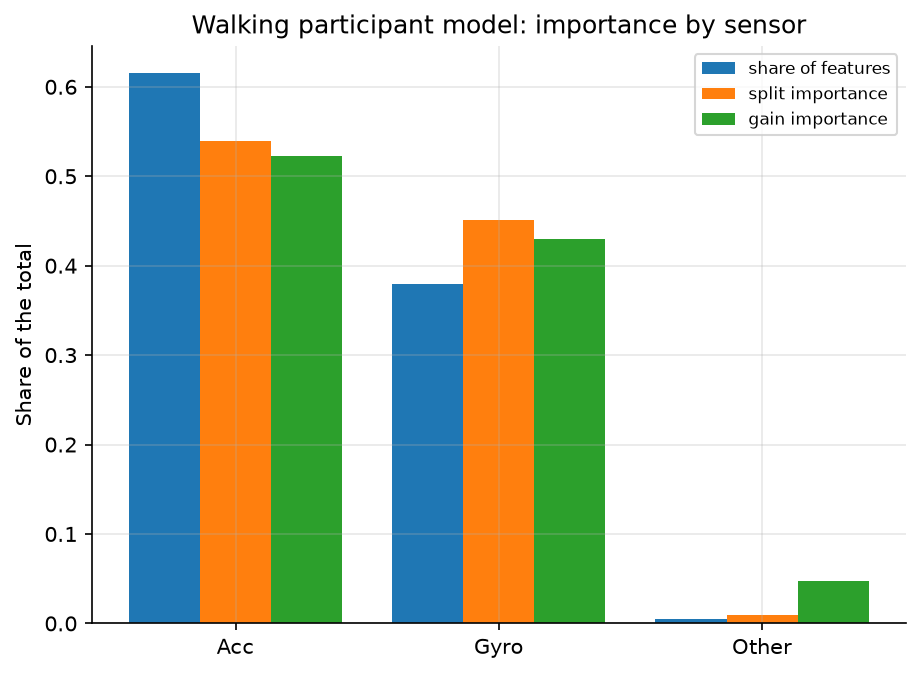

In [10]:
sensorTable = explorer.compareWalkingSensors()
display(readCsv(resultsDirectory / "walkingSensorImportance.csv"))
display(Image(filename=figuresDirectory / "walkingSensorImportance.png"))

## Stairs

This step compares the time each person spent going up and going down the stairs. The ratio of the two shows who walked up for longer than down. The figures show the times per person, the ratios in order and the spread of the times.

,subject,upstairsSeconds,downstairsSeconds,upDownRatio
0,1,67.84,62.72,1.081633
1,2,61.44,60.16,1.021277
2,3,75.52,62.72,1.204082
3,4,66.56,57.60,1.155556
4,5,60.16,60.16,1.000000
5,6,65.28,61.44,1.062500
6,7,65.28,60.16,1.085106
7,8,52.48,48.64,1.078947
8,9,62.72,53.76,1.166667
9,10,60.16,48.64,1.236842


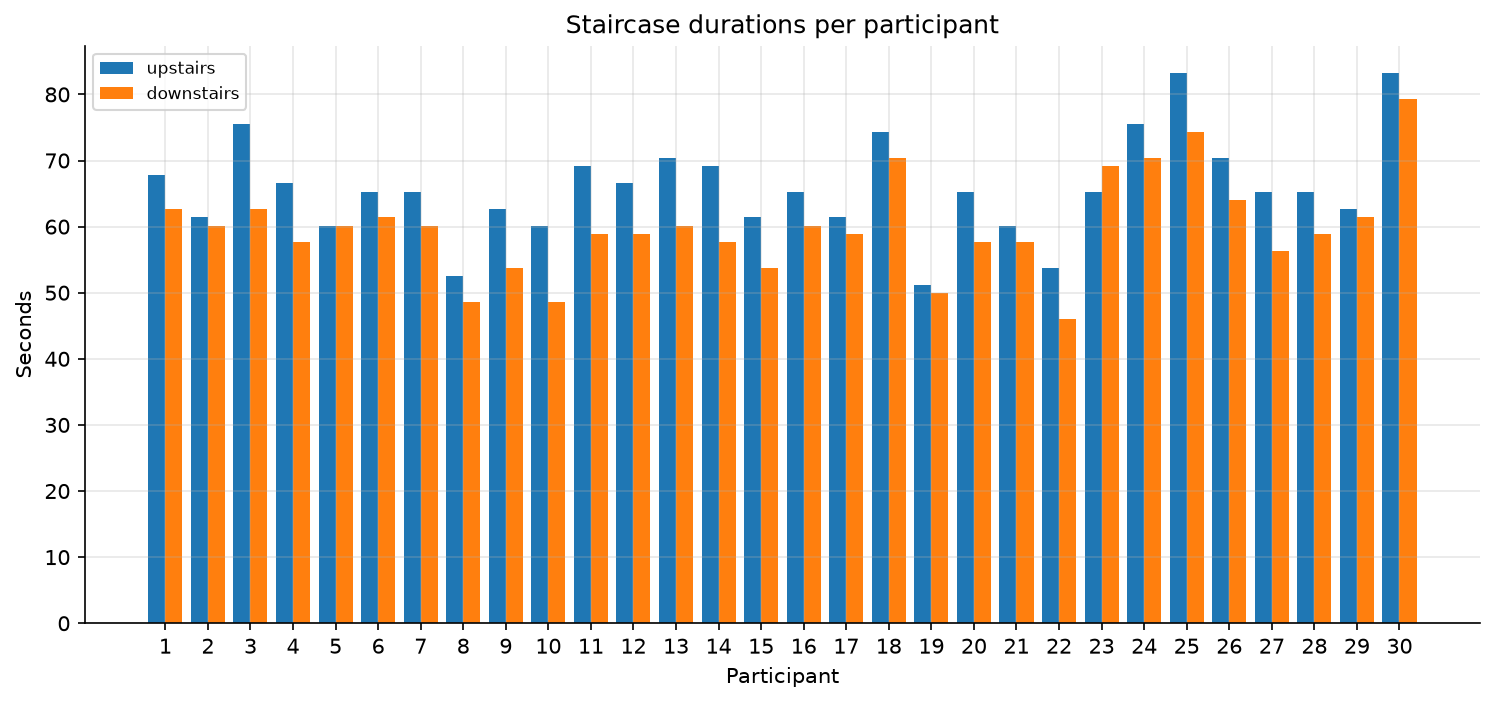

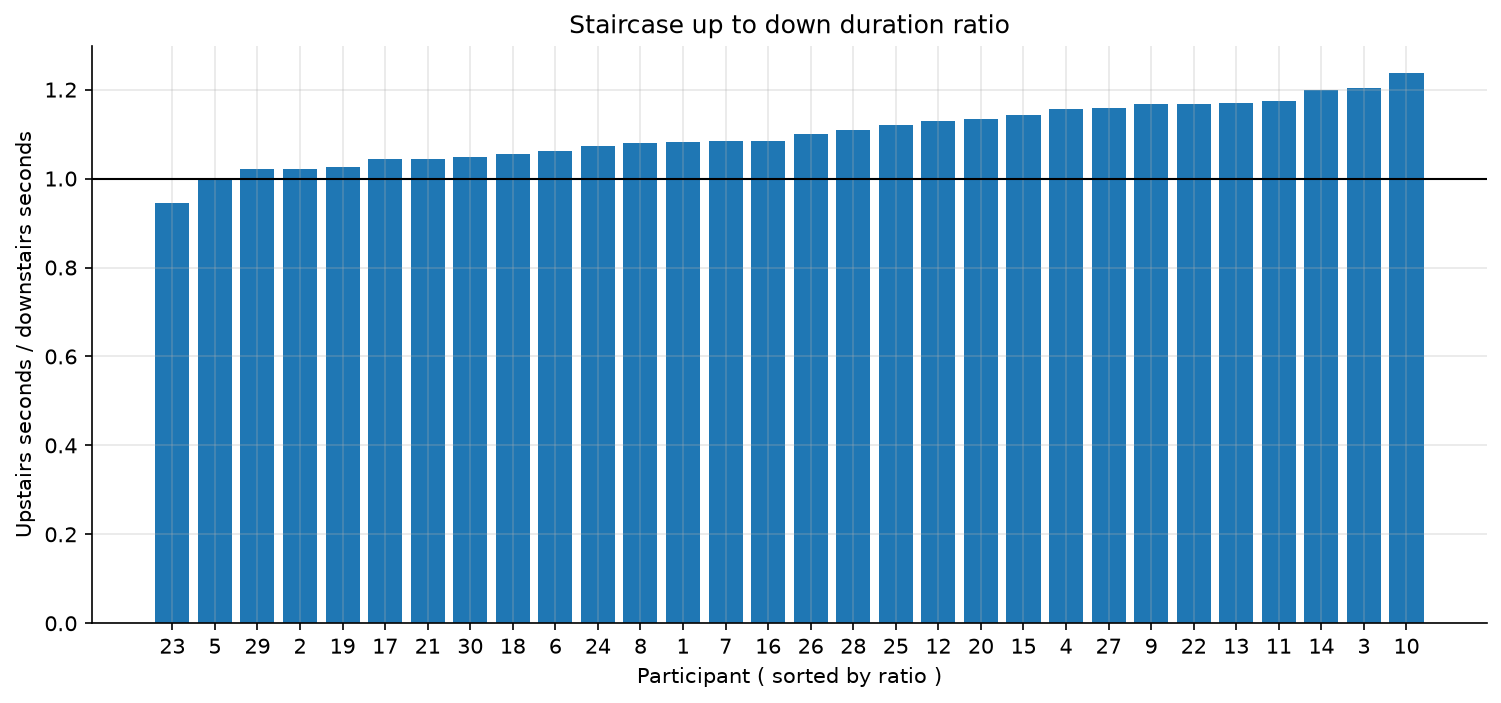

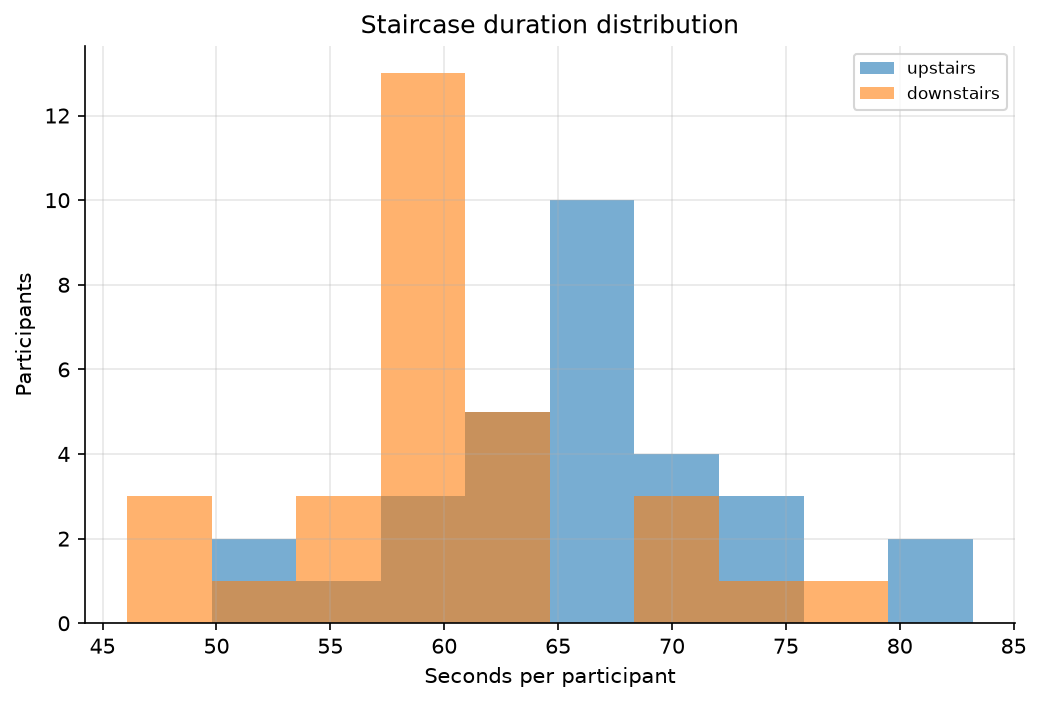

In [11]:
staircaseTable = explorer.exploreStaircase()
display(readCsv(resultsDirectory / "staircaseDurations.csv").head(10))
display(Image(filename=figuresDirectory / "staircaseDurations.png"))
display(Image(filename=figuresDirectory / "staircaseRatio.png"))
display(Image(filename=figuresDirectory / "staircaseHistogram.png"))

## Walking frequency with SSA

This step follows the original notebook. For each person it takes the average acceleration of the walking windows and splits it into parts with singular spectrum analysis. It then fits a sine wave to the two parts that look like an oscillation. Each window mean is an average over a long window, so this series can only show slow changes.

,subject,walkingWindows,ssaWindowLength,trendSingularShare,pairSingularShare,pairVarianceRatio,pairWCorrelation,wCorrelated,firstComponentPeakHz,secondComponentPeakHz,periodogramStartHz,ssaStepsPerSecond,sineAmplitude,sineRSquared,nyquistHz
0,1,95,47,0.977062,0.004892,0.255244,0.982431,True,0.148540,0.148026,0.148026,0.148061,0.028849,0.776152,0.390625
1,2,59,29,0.973463,0.007927,0.241733,0.987012,True,0.200278,0.199450,0.200278,0.200030,0.030750,0.774715,0.390625
2,3,58,29,0.972125,0.011270,0.379268,0.988212,True,0.139749,0.138066,0.138908,0.138718,0.037671,0.844449,0.390625
3,4,60,30,0.991735,0.002611,0.369941,0.968888,True,0.195312,0.193685,0.194499,0.194823,0.017828,0.459242,0.390625
4,5,56,28,0.974041,0.007959,0.424458,0.953083,True,0.293841,0.297328,0.294713,0.294517,0.033152,0.591629,0.390625
5,6,57,28,0.969126,0.010272,0.223854,0.974565,True,0.225295,0.222725,0.224438,0.224151,0.030430,0.699068,0.390625
6,7,57,28,0.972486,0.015018,0.459759,0.995228,True,0.277549,0.278406,0.277549,0.277877,0.047923,0.971672,0.390625
7,8,48,24,0.974011,0.007573,0.387715,0.865338,True,0.260417,0.266520,0.262451,0.262077,0.029702,0.440093,0.390625
8,9,52,26,0.992363,0.001785,0.155472,0.143022,False,0.390625,0.252592,0.390625,0.386172,0.012113,0.580230,0.390625
9,10,53,26,0.966429,0.015999,0.399290,0.974343,True,0.247826,0.250590,0.248747,0.249264,0.047733,0.809876,0.390625


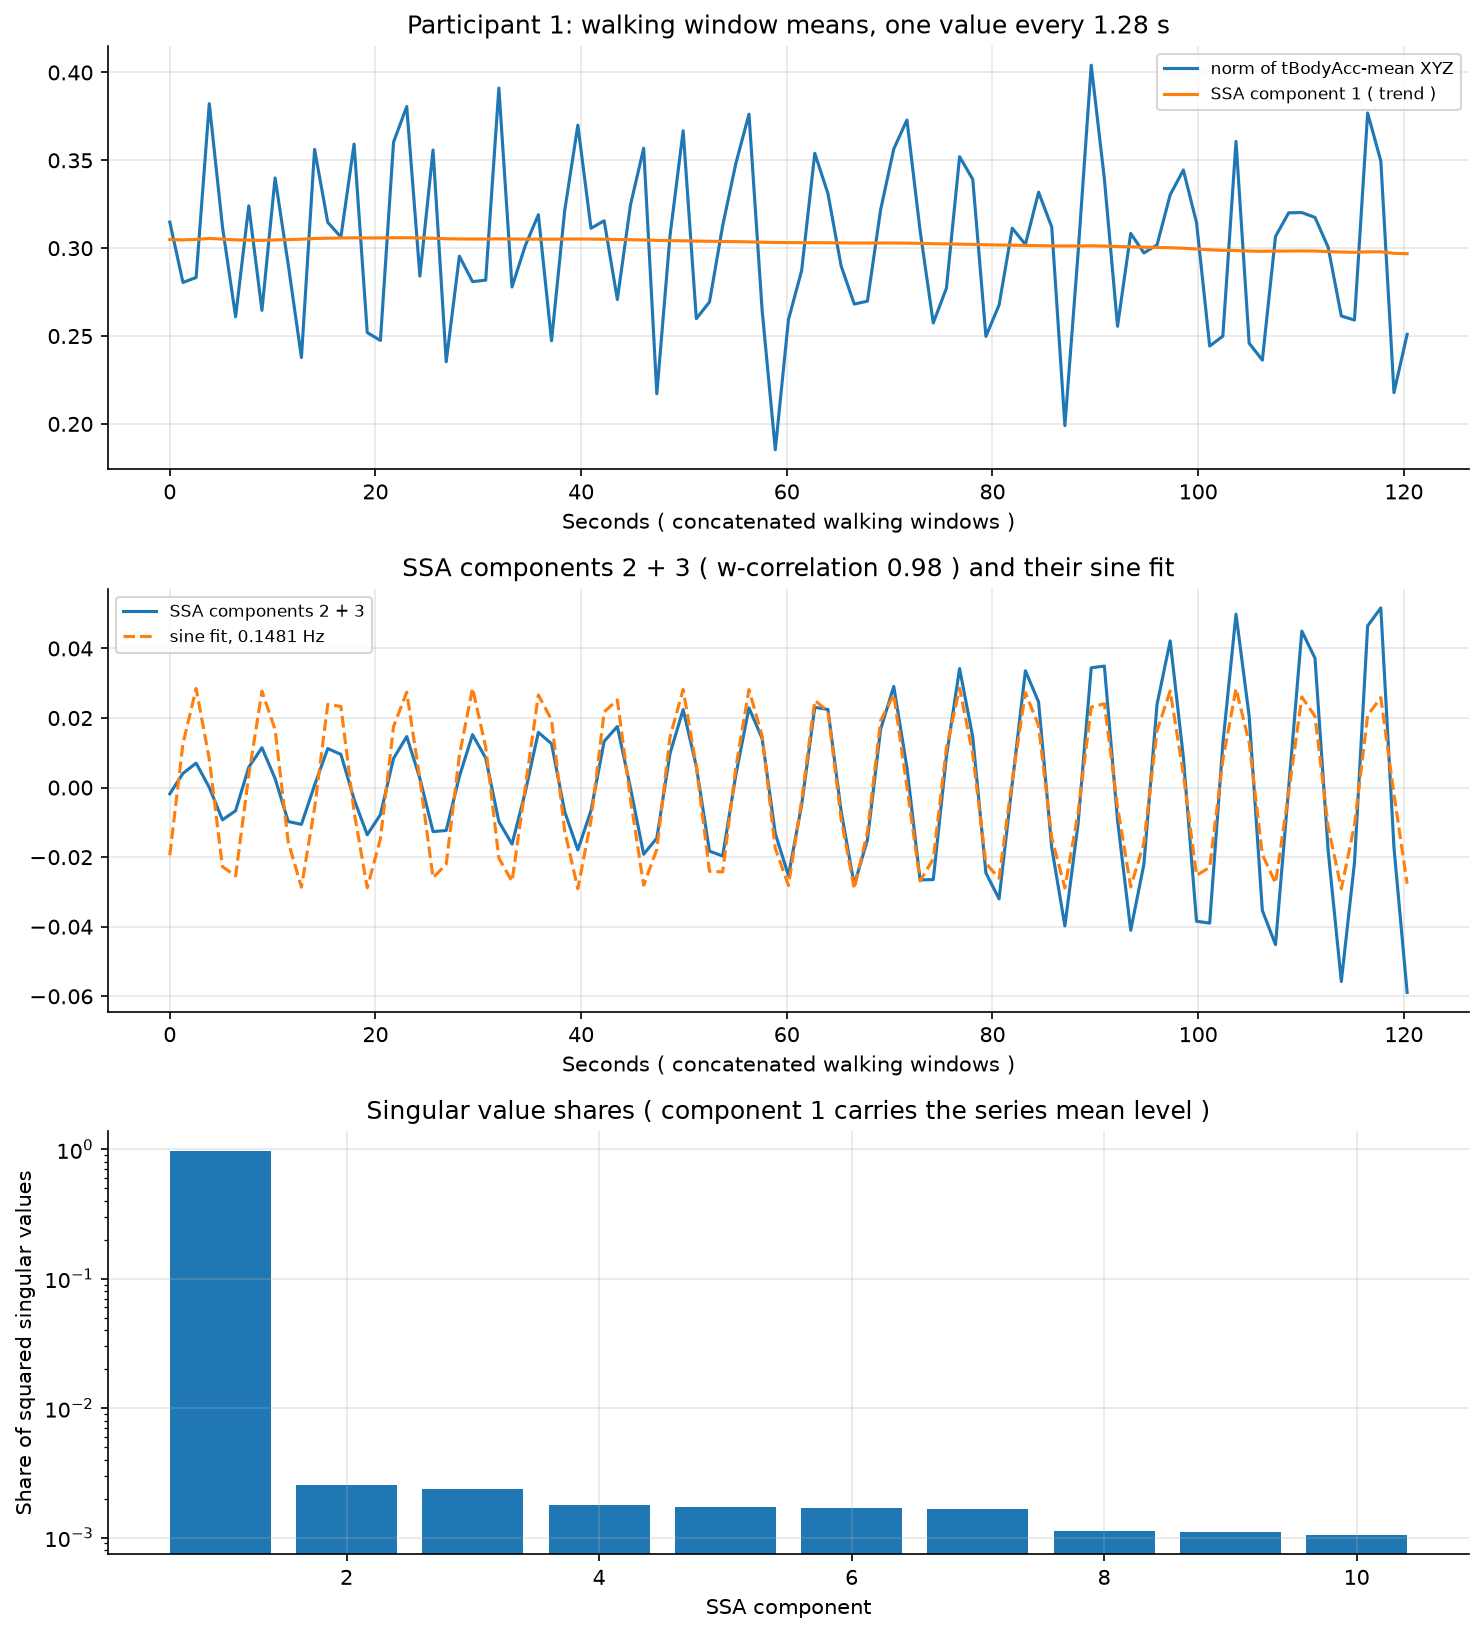

In [12]:
ssaTable = explorer.estimateWalkingFrequency()
display(readCsv(resultsDirectory / "ssaWalkingFrequency.csv").head(10))
display(Image(filename=figuresDirectory / "ssaWalkingFrequency.png"))

## Walking cadence from the raw signal

This step is an extension of the original notebook. It rebuilds each walking recording from the raw signal and estimates the steps per second in three ways. It then compares them with the SSA result from the last step. The last figure shows the spectrum of one person.

[ SMARTPHONE : MEDIAN RAW CADENCE ] : 1.773


,subject,walkingBouts,usedBouts,usedSeconds,fftStepsPerSecond,fftBoutMin,fftBoutMax,acfStepsPerSecond,acfRelativeToFft,verticalStepsPerSecond,verticalRelativeToFft,dominantPeakHz,dominantToStepRatio,dominantPeakIsStride,ssaStepsPerSecond,ssaToRawRatio,ssaNyquistHz
0,1,8,8,131.84,1.757812,1.672363,1.843262,1.758826,0.000577,1.766968,0.005208,0.885010,0.503472,True,0.148061,0.084230,0.390625
1,2,4,4,80.64,1.770020,1.733398,1.843262,1.782844,0.007246,1.776123,0.003448,1.788330,1.010345,False,0.200030,0.113010,0.390625
2,3,4,4,79.36,1.702881,1.599121,1.721191,1.696320,-0.003853,1.702881,0.000000,1.696777,0.996416,False,0.138718,0.081461,0.390625
3,4,4,4,81.92,1.934814,1.892090,1.977539,1.942087,0.003759,1.937866,0.001577,1.928711,0.996845,False,0.194823,0.100693,0.390625
4,5,4,4,76.80,1.788330,1.647949,1.855469,1.783116,-0.002916,1.794434,0.003413,0.897217,0.501706,True,0.294517,0.164688,0.390625
5,6,4,4,78.08,1.770020,1.721191,1.782227,1.754248,-0.008910,1.770020,0.000000,1.763916,0.996552,False,0.224151,0.126638,0.390625
6,7,4,4,78.08,1.849365,1.733398,1.879883,1.842323,-0.003808,1.846313,-0.001650,1.843262,0.996700,False,0.277877,0.150255,0.390625
7,8,5,4,65.28,1.885986,1.806641,1.928711,1.872602,-0.007097,1.882935,-0.001618,0.927734,0.491909,True,0.262077,0.138960,0.390625
8,9,4,4,71.68,1.934814,1.904297,1.989746,1.918733,-0.008312,1.937866,0.001577,0.964355,0.498423,True,0.386172,0.199591,0.390625
9,10,4,4,72.96,1.794434,1.794434,1.843262,1.792601,-0.001021,1.797485,0.001701,0.903320,0.503401,True,0.249264,0.138909,0.390625


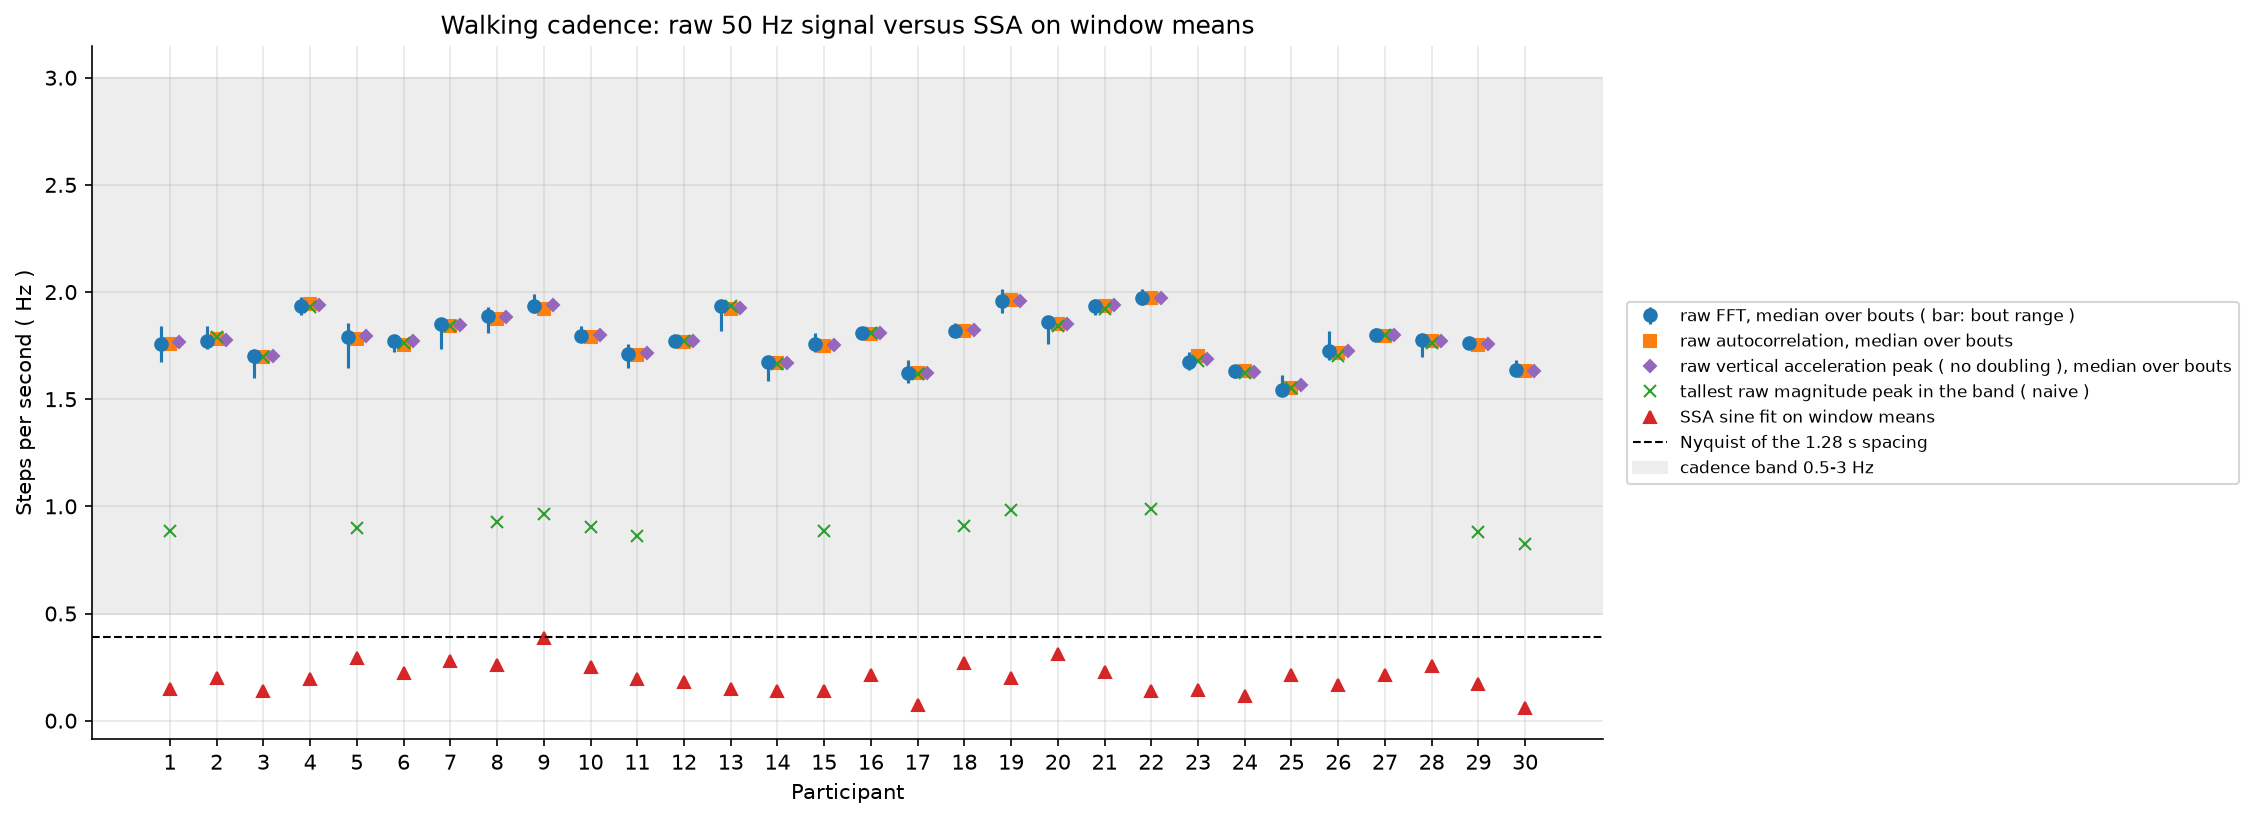

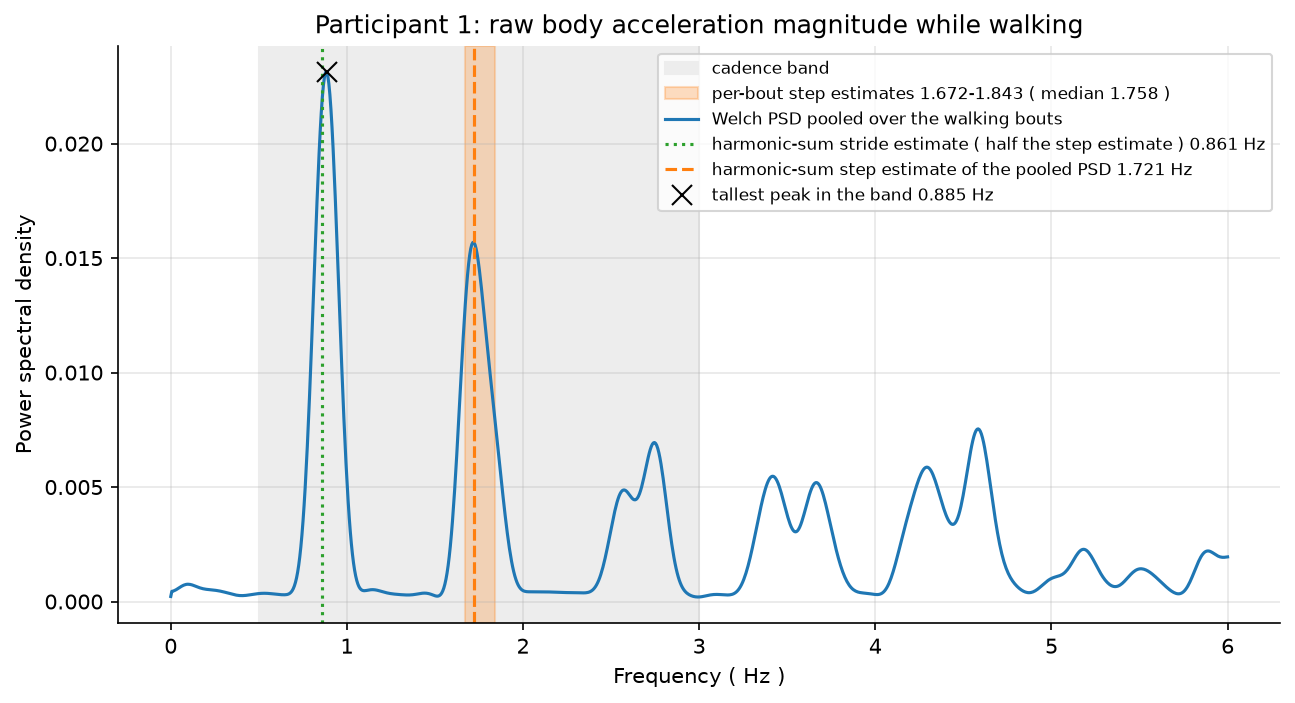

In [13]:
cadenceTable = explorer.estimateRawCadence()
display(readCsv(resultsDirectory / "cadenceComparison.csv").head(10))
display(Image(filename=figuresDirectory / "cadenceComparison.png"))
display(Image(filename=figuresDirectory / f"rawSpectrumParticipant{explorer.ssaParticipant}.png"))

## Run parameters

This step saves the settings and the checks of the run in one table. It also lists the versions of the software that was used.

In [14]:
parameterTable = explorer.writeParameters()
display(readCsv(resultsDirectory / "runParameters.csv").head(10))

,section,parameter,value
0,run,randomSeed,42
1,run,nJobs,4
2,run,python,3.12.14
3,run,numpy,2.5.3
4,run,pandas,3.0.6
5,run,scipy,1.18.1
6,run,scikit-learn,1.9.1
7,run,lightgbm,4.7.0
8,run,matplotlib,3.11.2
9,data,windows,10299
